# Wrong-sign neutrinos from neutrino interactions in the rock

The forward beams are flavor-pure at production: the $\mu^-$ beam contains
$\{\nu_\mu, \bar\nu_e\}$ and the $\mu^+$ beam $\{\bar\nu_\mu, \nu_e\}$.
Neutrino interactions in the rock upstream of the detectors regenerate the
**wrong-sign** partners — $\bar\nu_\mu, \nu_e$ in the $\mu^-$ beam and
$\nu_\mu, \bar\nu_e$ in the $\mu^+$ beam — an irreducible contamination for
any sign-tagged measurement. Two prompt sources survive the rock (shower
$\pi/K$ are absorbed long before decaying, and tertiary muons stop and decay
at rest, far below threshold):

1. **Inverse muon decay on the rock electrons** ($\mu^-$-beam flavors only,
   by lepton number) — the *prompt partner neutrino*:
   $\nu_\mu e^- \to \mu^-\, \nu_e$ (t-channel, isotropic CM) and
   $\bar\nu_e e^- \to \mu^-\, \bar\nu_\mu$ (s-channel annihilation,
   $(1+\cos\theta^*)^2$). Threshold $m_\mu^2/2m_e = 10.9$ GeV; collinear
   ($\gamma_{\rm CM}\sim 10^3$) and hard, so the **whole rock column
   contributes** — like the inverse tau decay of the $\nu_\tau$ study.
2. **Mixed $e\mu$ neutrino tridents** on the rock nuclei — the prompt
   outgoing neutrino IS the wrong-sign flavor, with no mass suppression:
   $\nu_\mu A \to \nu_e\, \mu^- e^+ A$, $\bar\nu_e A \to \bar\nu_\mu\, e^+\mu^- A$
   (and conjugates for the $\mu^+$ beam). Cross sections and exact
   four-vector kinematics from NEPTUNE, reusing the $\ell\tau$-trident
   machinery of notebook 2 (coherent + diffractive, anchor pools,
   two-anchor interpolation); the charged leptons range out in the rock.
   Hard and collinear, so this source dominates the wrong-sign flux at the
   highest energies.
3. **Charm production**, using the same dimuon-standard machinery as the
   $\nu_\tau$ chains: $\nu$ CC charm, $c\to D^0/D^\pm/D_s$ (fractions
   0.60/0.26/0.08), then the 3-body semileptonic decay $D \to X \ell\nu$
   whose neutrino carries the charm lepton number:
   $\bar\nu_e \to \bar c \to D^- \to \mu^-\bar\nu_\mu X$ (wrong-sign
   $\bar\nu_\mu$ in the $\mu^-$ beam), $\nu_e \to c \to D^+ \to
   \mu^+\nu_\mu X$ (wrong-sign $\nu_\mu$ in the $\mu^+$ beam), and the
   $e$-mode analogues for the wrong-sign $\nu_e/\bar\nu_e$. Two-body
   leptonic and 4-body modes neglected (per-mille), as are $\Lambda_c$
   ($f\simeq 6\%$, ${\rm BR}_{\rm sl}\simeq 4\%$) and NC charm pairs.

Everything runs in the same MC infrastructure as notebook 2: shared charm
production (`_charm_quark`: flux $\times\sigma_{\rm charm}$ energy sampling,
CCFR strange sea, slow rescaling, Peterson + $p_T$ fragmentation), shared
two-body boost helpers, same rock geometry and acceptance
($\theta \cdot L_{\rm rem} < r_{\rm det}$).

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

import mint
mint.xsecs.use_backend("ct18")   # PDF-consistent LO CT18NNLO cross sections
from mint import const
from mint import detector_tools as dt
from mint import plot_tools as pt
from mint import xsecs

import nutau_secondary as nts

## 1. Primary fluxes and source cross sections

/Users/mhostert/Repos/MINT/mint/MuC.py:442: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


numubar : 2.231e+18 nu/yr through the face


nue     : 2.215e+18 nu/yr through the face


numu    : 2.224e+18 nu/yr through the face


nuebar  : 2.223e+18 nu/yr through the face


/Users/mhostert/Repos/neptune/src/neptune/nuclear_tools.py:203: RuntimeWarning: overflow encountered in sinh
  den = safe_q**3 * np.sinh(np.pi * safe_q * a) * (r0**2 + np.pi**2 * a**2) * r0
/Users/mhostert/Repos/neptune/src/neptune/nuclear_tools.py:203: RuntimeWarning: overflow encountered in multiply
  den = safe_q**3 * np.sinh(np.pi * safe_q * a) * (r0**2 + np.pi**2 * a**2) * r0



effective semileptonic BR per charm CC and lepton flavor: 0.0859


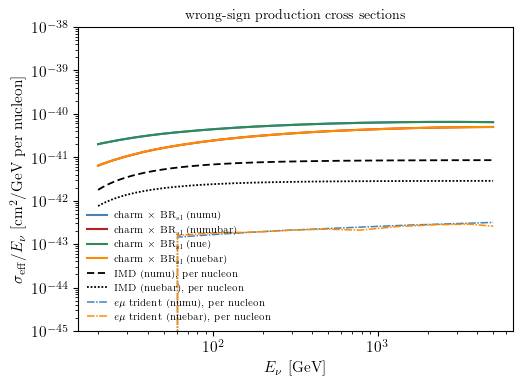

In [2]:
ring, sims, injections_per_year = mint.examples.both_beams(n_evals=5e5)
det = mint.detectors.load("benchmark_5km")
DIST, DET_R, GAP = det.dist, det.radius, det.gap
Lss_half, rock = det.rock_start, det.rock
col_det = det.nucleon_column()

FLUX = {}       # binned quadrature grid: MC sampling / xsec folding input
FLUX_RAW = {}   # raw MC flux: use THIS for spectra and rebinned rates
for lab, sign in [("numubar", +1), ("nue", +1), ("numu", -1), ("nuebar", -1)]:
    E_, w_, _ = det.flux_with_chords(sims[lab], sign=sign,
                                     exposure=injections_per_year)
    FLUX[lab] = dt.bin_flux(E_, w_)
    FLUX_RAW[lab] = (E_, w_)
    print(f"{lab:8s}: {w_.sum():.3e} nu/yr through the face")

Enu_edges = np.geomspace(5, 5000, 34)
Enu_c = np.sqrt(Enu_edges[1:] * Enu_edges[:-1])
dE = np.diff(Enu_edges)

# effective per-nucleon cross sections of the two wrong-sign sources
fig, ax = pt.std_fig(figsize=(5.5, 4))
Eg = np.geomspace(20, 5e3, 200)
n_e_per_nucleon = rock.Z / rock.A
for lab, c in [("numu", "steelblue"), ("numubar", "firebrick"),
               ("nue", "seagreen"), ("nuebar", "darkorange")]:
    ax.plot(Eg, nts.sigma_charm_cc(Eg, lab) * nts.wrongsign_br_eff() / Eg,
            color=c, lw=1.5, label=rf"charm $\times$ BR$_{{\rm sl}}$ ({lab})")
for lab, ls in [("numu", (0, (4, 2))), ("nuebar", (0, (1, 1)))]:
    sig = np.clip(xsecs.inverse_lepton_decay_sigma(Eg, lab, "m"), 0, None)
    ax.plot(Eg, sig * n_e_per_nucleon / Eg, color="k", lw=1.3, ls=ls,
            label=f"IMD ({lab}), per nucleon")
for lab, c in [("numu", "steelblue"), ("nuebar", "darkorange")]:
    sig = nts.sigma_trident(Eg, lab, channel="emu") / nts.TRIDENT_A_ROCK
    ax.plot(Eg, sig / Eg, color=c, lw=1.1, ls=(0, (5, 1, 1, 1)),
            label=rf"$e\mu$ trident ({lab}), per nucleon")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1e-45, 1e-38)
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$\sigma_{\rm eff}/E_\nu$ [cm$^2$/GeV per nucleon]")
ax.legend(frameon=False, fontsize=7)
ax.set_title("wrong-sign production cross sections", fontsize=10)
fig.savefig("plots/wrongsign_xsecs.pdf", bbox_inches="tight", dpi=300)
print(f"\neffective semileptonic BR per charm CC and lepton flavor: "
      f"{nts.wrongsign_br_eff():.4f}")

## 2. Validation: decay and IMD kinematics

The $D\to X\ell\nu$ neutrino spectrum in the $D$ frame is sampled on the
Dalitz plane with the constant-$f_+$ V--A matrix element
$|M|^2 = 2(V\!\cdot\!p_\ell)(V\!\cdot\!p_\nu) - V^2 (p_\ell\!\cdot\!p_\nu)$,
$V = p_D + p_X$; we check it against a direct numerical integration of the
same $|M|^2$. The IMD prompt-neutrino energy fractions must come out flat
($\nu_\mu$ channel, isotropic t-channel) and $\propto u^2$ ($\bar\nu_e$
annihilation, from the $(1+\cos\theta^*)^2$ V--A weight).

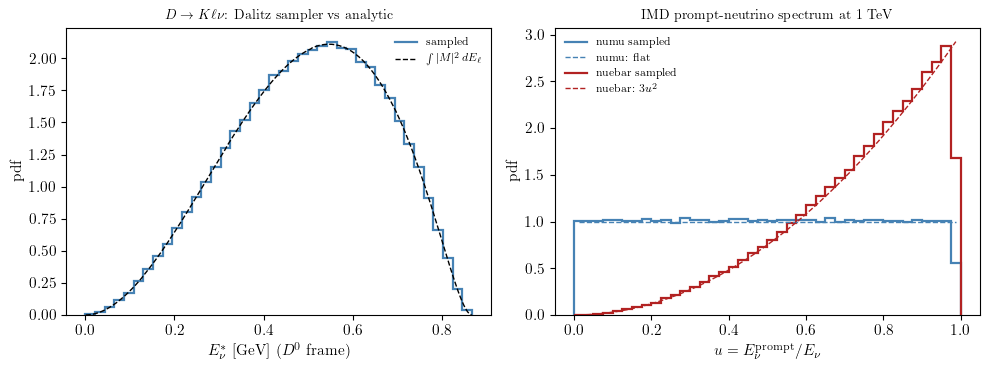

In [3]:
rngv = np.random.default_rng(7)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))

# D-frame nu spectrum vs direct |M|^2 integration
M_D, m_X = nts.M_D0, nts._SL_MHAD["D0"]
Ev = nts._sample_semileptonic_nu(M_D, m_X, 400_000, rngv)
E_max = (M_D**2 - m_X**2) / (2 * M_D)
eb = np.linspace(0, E_max, 41)
h = np.histogram(Ev, bins=eb, density=True)[0]
ax[0].stairs(h, eb, color="steelblue", lw=1.6, label="sampled")
# analytic: integrate |M|^2 over El at fixed Ev
Evg = np.linspace(1e-3, E_max - 1e-3, 200)
spec = []
for ev in Evg:
    El = np.linspace(1e-4, E_max, 2000)
    q2 = m_X**2 - M_D**2 + 2 * M_D * (El + ev)
    ok = (q2 >= 0) & (q2 <= 4 * El * ev)
    V2 = 2 * (M_D**2 + m_X**2) - q2
    w = 2 * (2 * M_D * El - q2 / 2) * (2 * M_D * ev - q2 / 2) - V2 * q2 / 2
    spec.append(np.trapezoid(np.where(ok, np.clip(w, 0, None), 0.0), El))
spec = np.array(spec)
ax[0].plot(Evg, spec / np.trapezoid(spec, Evg), "k--", lw=1.0,
           label=r"$\int |M|^2\, dE_\ell$")
ax[0].set_xlabel(r"$E_\nu^*$ [GeV] ($D^0$ frame)")
ax[0].set_ylabel("pdf")
ax[0].legend(frameon=False, fontsize=8)
ax[0].set_title(r"$D \to K \ell\nu$: Dalitz sampler vs analytic", fontsize=10)

# IMD prompt-nu energy fractions
Etest = np.full(300_000, 1000.0)
for lab, c, ana, txt in [
        ("numu", "steelblue", lambda u: np.ones_like(u), "flat"),
        ("nuebar", "firebrick", lambda u: 3 * u**2, r"$3u^2$")]:
    E_i, _ = nts.sample_imd_prompt(300_000, np.array([1000.0]), np.array([1.0]),
                                   lab, rng=rngv)
    u = E_i / 1000.0
    ub = np.linspace(0, 1, 41)
    h = np.histogram(u, bins=ub, density=True)[0]
    ax[1].stairs(h, ub, color=c, lw=1.6, label=f"{lab} sampled")
    uc = 0.5 * (ub[1:] + ub[:-1])
    ax[1].plot(uc, ana(uc), "--", color=c, lw=1.0, label=f"{lab}: {txt}")
ax[1].set_xlabel(r"$u = E_\nu^{\rm prompt}/E_\nu$")
ax[1].set_ylabel("pdf")
ax[1].legend(frameon=False, fontsize=8)
ax[1].set_title("IMD prompt-neutrino spectrum at 1 TeV", fontsize=10)
plt.tight_layout()
fig.savefig("plots/wrongsign_validation.pdf", bbox_inches="tight", dpi=300)

## 3. Wrong-sign fluxes at the two detectors

Per beam and wrong-sign flavor (the charm $e$- and $\mu$-mode kinematics and
BRs are equal in the massless-lepton limit, so one charm MC serves both):

| detector | wrong-sign flavor | sources |
| --- | --- | --- |
| upstream ($\mu^-$ beam) | $\bar\nu_\mu$ | charm($\bar\nu_e$) $\mu$-modes + IMD($\bar\nu_e$) + trident($\bar\nu_e$) |
| upstream ($\mu^-$ beam) | $\nu_e$ | charm($\nu_\mu$) $e$-modes + IMD($\nu_\mu$) + trident($\nu_\mu$) |
| downstream ($\mu^+$ beam) | $\nu_\mu$ | charm($\nu_e$) $\mu$-modes + trident($\nu_e$) |
| downstream ($\mu^+$ beam) | $\bar\nu_e$ | charm($\bar\nu_\mu$) $e$-modes + trident($\bar\nu_\mu$) |

charm(numubar ): wrong-sign nu through the face 7.874e+09 /yr


charm(nue     ): wrong-sign nu through the face 8.029e+09 /yr


charm(numu    ): wrong-sign nu through the face 1.049e+10 /yr


charm(nuebar  ): wrong-sign nu through the face 6.102e+09 /yr
IMD  (numu    ): prompt wrong-sign nu through the face 1.207e+10 /yr
IMD  (nuebar  ): prompt wrong-sign nu through the face 5.136e+09 /yr


/Users/mhostert/Repos/neptune/src/neptune/nuclear_tools.py:203: RuntimeWarning: overflow encountered in sinh
  den = safe_q**3 * np.sinh(np.pi * safe_q * a) * (r0**2 + np.pi**2 * a**2) * r0
/Users/mhostert/Repos/neptune/src/neptune/nuclear_tools.py:203: RuntimeWarning: overflow encountered in multiply
  den = safe_q**3 * np.sinh(np.pi * safe_q * a) * (r0**2 + np.pi**2 * a**2) * r0


trident(numubar ): prompt wrong-sign nu through the face 1.164e+08 /yr


trident(nue     ): prompt wrong-sign nu through the face 9.218e+07 /yr


trident(numu    ): prompt wrong-sign nu through the face 1.448e+08 /yr


trident(nuebar  ): prompt wrong-sign nu through the face 1.064e+08 /yr


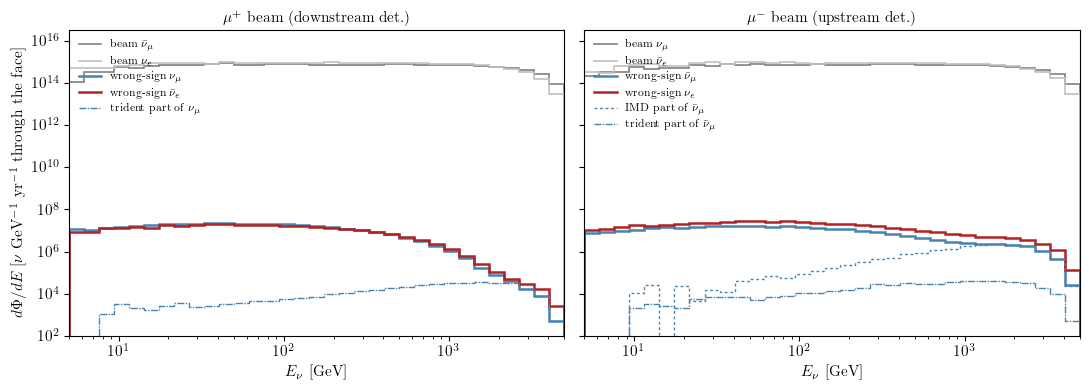

In [4]:
# charm-induced wrong-sign fluxes (one call per primary flavor)
ws_charm = {}
for prim in ("numubar", "nue", "numu", "nuebar"):
    Ec, W = FLUX[prim]
    ws_charm[prim] = nts.wrongsign_flux_charm_mc(
        Ec, W, prim, rock, Lss_half, DIST - GAP, DIST, DET_R, Enu_edges,
        n_mc=500_000, rng=31)
    print(f"charm({prim:8s}): wrong-sign nu through the face "
          f"{ws_charm[prim].sum():.3e} /yr")

# prompt-IMD wrong-sign fluxes (mu- beam only)
ws_imd = {}
for prim in ("numu", "nuebar"):
    Ec, W = FLUX[prim]
    ws_imd[prim] = nts.wrongsign_flux_imd_mc(
        Ec, W, prim, rock, Lss_half, DIST - GAP, DIST, DET_R, Enu_edges,
        n_mc=300_000, rng=32)
    print(f"IMD  ({prim:8s}): prompt wrong-sign nu through the face "
          f"{ws_imd[prim].sum():.3e} /yr")

# mixed e-mu tridents (all four primaries; the prompt nu is the wrong sign)
ws_tri = {}
for prim in ("numubar", "nue", "numu", "nuebar"):
    Ec, W = FLUX[prim]
    ws_tri[prim] = nts.wrongsign_flux_trident_mc(
        Ec, W, prim, rock, Lss_half, DIST - GAP, DIST, DET_R, Enu_edges,
        n_mc=300_000, rng=33)
    print(f"trident({prim:8s}): prompt wrong-sign nu through the face "
          f"{ws_tri[prim].sum():.3e} /yr")

# assemble per detector / wrong-sign flavor
WS = {
    ("up", "numubar"): ws_charm["nuebar"] + ws_imd["nuebar"] + ws_tri["nuebar"],
    ("up", "nue"):     ws_charm["numu"] + ws_imd["numu"] + ws_tri["numu"],
    ("down", "numu"):  ws_charm["nue"] + ws_tri["nue"],
    ("down", "nuebar"): ws_charm["numubar"] + ws_tri["numubar"],
}

fig, axs = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, side, beam in [(axs[0], "down", r"$\mu^+$ beam (downstream det.)"),
                       (axs[1], "up", r"$\mu^-$ beam (upstream det.)")]:
    prim_labels = {"down": [("numubar", r"beam $\bar\nu_\mu$", "gray"),
                            ("nue", r"beam $\nu_e$", "silver")],
                   "up": [("numu", r"beam $\nu_\mu$", "gray"),
                          ("nuebar", r"beam $\bar\nu_e$", "silver")]}[side]
    for prim, lab, c in prim_labels:
        # RAW flux histogram (re-histogramming the binned grid aliases into
        # a castle-wall pattern)
        E_, w_ = FLUX_RAW[prim]
        Wb = np.histogram(E_, bins=Enu_edges, weights=w_)[0]
        ax.stairs(Wb / dE, Enu_edges, color=c, lw=1.2, label=lab)
    for (s_, fl), col, lab in [
            (("down", "numu"), "steelblue", r"wrong-sign $\nu_\mu$"),
            (("down", "nuebar"), "firebrick", r"wrong-sign $\bar\nu_e$"),
            (("up", "numubar"), "steelblue", r"wrong-sign $\bar\nu_\mu$"),
            (("up", "nue"), "firebrick", r"wrong-sign $\nu_e$")]:
        if s_ != side:
            continue
        ax.stairs(WS[(s_, fl)] / dE, Enu_edges, color=col, lw=1.8, label=lab)
    if side == "up":
        ax.stairs(ws_imd["nuebar"] / dE, Enu_edges, color="steelblue", lw=1.0,
                  ls=(0, (2, 2)), label=r"IMD part of $\bar\nu_\mu$")
        ax.stairs(ws_tri["nuebar"] / dE, Enu_edges, color="steelblue", lw=1.0,
                  ls=(0, (5, 1, 1, 1)), label=r"trident part of $\bar\nu_\mu$")
    else:
        ax.stairs(ws_tri["nue"] / dE, Enu_edges, color="steelblue", lw=1.0,
                  ls=(0, (5, 1, 1, 1)), label=r"trident part of $\nu_\mu$")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(Enu_edges[0], Enu_edges[-1])
    ax.set_ylim(1e2, 3e16)
    ax.set_xlabel(r"$E_\nu$ [GeV]")
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    ax.set_title(beam, fontsize=11)
axs[0].set_ylabel(r"$d\Phi/dE$ [$\nu$ GeV$^{-1}$ yr$^{-1}$ through the face]")
plt.tight_layout()
fig.savefig("plots/wrongsign_flux.pdf", bbox_inches="tight", dpi=300)

## 4. CC event rates and the sign contamination

Wrong-sign CC events per year in the benchmark detector (per-flavor CC cross
sections with the non-isoscalar column correction), compared with the
right-sign beam rates. The contamination is quoted both as a total-rate ratio
and per energy bin — the charm component is soft, while the IMD $\bar\nu_\mu$
line rides at $u^2$-weighted TeV energies where a wrong-sign muon would be
most conspicuous.

  detector     flavor   wrong-sign CC/yr     beam CC/yr      ratio
        up    numubar              1.018      6.082e+08   1.67e-09
        up        nue              4.106      2.863e+08   1.43e-08
      down       numu              0.463      3.346e+08   1.38e-09
      down     nuebar              0.257      5.252e+08   4.89e-10


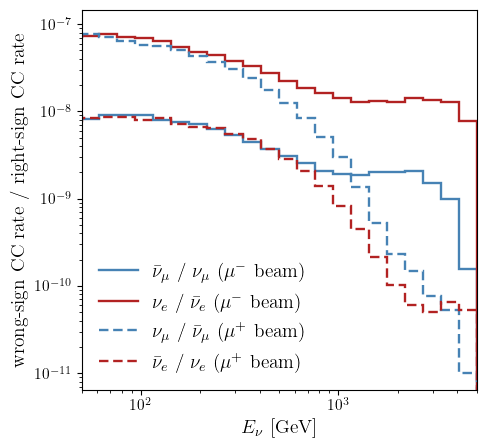

In [5]:
def cc_events(flux_binned, flavor):
    sig = (xsecs.sigma_CC(Enu_c, flavor)
           * det.cc_correction(Enu_c, flavor))
    return float(np.sum(flux_binned * sig * col_det)), flux_binned * sig * col_det

print(f"{'detector':>10s} {'flavor':>10s} {'wrong-sign CC/yr':>18s} "
      f"{'beam CC/yr':>14s} {'ratio':>10s}")
ratios = {}
for (side, fl), ws in WS.items():
    N_ws, spec_ws = cc_events(ws, fl)
    beam_of = {("up", "numubar"): "numu", ("up", "nue"): "nuebar",
               ("down", "numu"): "numubar", ("down", "nuebar"): "nue"}[(side, fl)]
    E_, w_ = FLUX_RAW[beam_of]          # raw flux: no rebinning aliasing
    Wb = np.histogram(E_, bins=Enu_edges, weights=w_)[0]
    N_beam, spec_beam = cc_events(Wb, beam_of)
    ratios[(side, fl)] = (spec_ws, spec_beam)
    print(f"{side:>10s} {fl:>10s} {N_ws:18.3f} {N_beam:14.3e} "
          f"{N_ws / N_beam:10.2e}")

fig, ax = pt.std_fig(figsize=(5, 5))
for (side, fl), col, lab in [
        (("up", "numubar"), "steelblue", r"$\bar\nu_\mu$ / $\nu_\mu$ ($\mu^-$ beam)"),
        (("up", "nue"), "firebrick", r"$\nu_e$ / $\bar\nu_e$ ($\mu^-$ beam)"),
        (("down", "numu"), "steelblue", r"$\nu_\mu$ / $\bar\nu_\mu$ ($\mu^+$ beam)"),
        (("down", "nuebar"), "firebrick", r"$\bar\nu_e$ / $\nu_e$ ($\mu^+$ beam)")]:
    spec_ws, spec_beam = ratios[(side, fl)]
    r = np.where(spec_beam > 0, spec_ws / np.maximum(spec_beam, 1e-300), np.nan)
    ls = "-" if side == "up" else (0, (4, 2))
    ax.stairs(r, Enu_edges, color=col, lw=1.7, ls=ls, label=lab)
# ax.stairs([np.nan] * (len(Enu_edges) - 1), Enu_edges, color="gray", lw=1.7,
        #   ls=(0, (4, 2)), label=r"$\mu^+$ beam (dashed)")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(Enu_edges[0], Enu_edges[-1])
ax.set_xlabel(r"$E_\nu$ [GeV]", fontsize=14)
ax.set_ylabel("wrong-sign CC rate / right-sign CC rate", fontsize=14)
ax.legend(frameon=False, fontsize=14)
ax.set_xlim(50, 5000)
fig.savefig("plots/wrongsign_contamination.pdf", bbox_inches="tight", dpi=300)

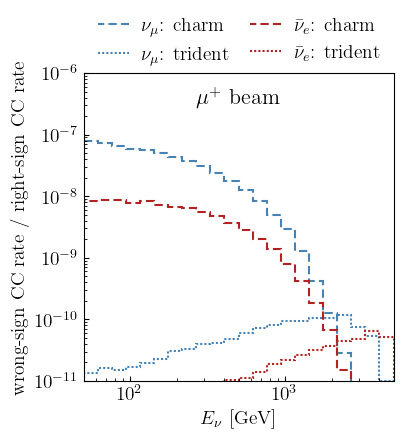

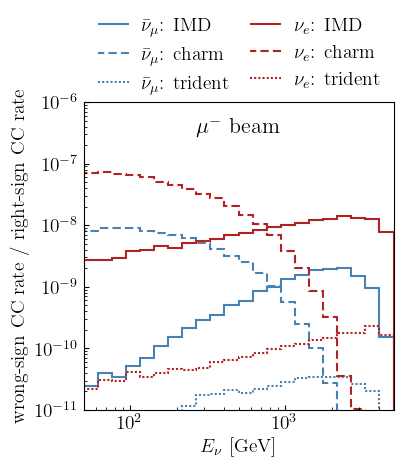

In [6]:
def cc_spec(flux_binned, flavor):
    sig = xsecs.sigma_CC(Enu_c, flavor) * det.cc_correction(Enu_c, flavor)
    return flux_binned * sig * col_det


fl_tex = {
    "numu": r"$\nu_\mu$",
    "numubar": r"$\bar\nu_\mu$",
    "nue": r"$\nu_e$",
    "nuebar": r"$\bar\nu_e$",
}

channel_cfg = {
    ("up", "numubar"): {"prim": "nuebar", "beam_of": "numu"},
    ("up", "nue"): {"prim": "numu", "beam_of": "nuebar"},
    ("down", "numu"): {"prim": "nue", "beam_of": "numubar"},
    ("down", "nuebar"): {"prim": "numubar", "beam_of": "nue"},
}


for side, title in [
    ("down", r"$\mu^+$ beam"),
    ("up", r"$\mu^-$ beam"),
]:
    fig, ax = plt.subplots(figsize=(4, 4))

    flavors = (
        [("numu", "steelblue"), ("nuebar", "firebrick")]
        if side == "down"
        else [("numubar", "steelblue"), ("nue", "firebrick")]
    )

    for fl, col in flavors:
        cfg = channel_cfg[(side, fl)]
        prim = cfg["prim"]
        beam_of = cfg["beam_of"]

        E_raw, w_raw = FLUX_RAW[beam_of]
        Wb = np.histogram(E_raw, bins=Enu_edges, weights=w_raw)[0]
        spec_beam = cc_spec(Wb, beam_of)

        src_flux = {
            "charm": ws_charm[prim],
            "IMD": ws_imd[prim] if prim in ws_imd else np.zeros_like(ws_charm[prim]),
            "trident": ws_tri[prim],
        }
        src_ls = {"charm": (1,(4,2)), "trident": (0, (1, 1)), "IMD": (0, (4, 0))}

        for src in ("IMD", "charm", "trident"):
            spec_src = cc_spec(src_flux[src], fl)
            if not np.any(spec_src > 0):
                continue
            r_src = np.where(
                spec_beam > 0,
                spec_src / np.maximum(spec_beam, 1e-300),
                np.nan,
            )
            ax.stairs(
                r_src,
                Enu_edges,
                color=col,
                lw=1.5,
                ls=src_ls[src],
                label=rf"{fl_tex[fl]}: {src}",
            )

        # spec_tot = cc_spec(WS[(side, fl)], fl)
        # r_tot = np.where(
        #     spec_beam > 0,
        #     spec_tot / np.maximum(spec_beam, 1e-300),
        #     np.nan,
        # )
        # ax.stairs(
        #     r_tot,
        #     Enu_edges,
        #     color=col,
        #     lw=2.0,
        #     label=rf"{fl_tex[fl]}: total",
        # )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.tick_params(axis="both", which="both", direction="in", labelsize=14)
    ax.set_xlim(50, 5000)
    ax.set_ylim(1e-11, 1e-6)
    ax.set_ylabel("wrong-sign CC rate / right-sign CC rate", fontsize=14)
    ax.set_xlabel(r"$E_\nu$ [GeV]", fontsize=14)
    ax.annotate(title, fontsize=16, xy=(0.5, 0.9), xycoords="axes fraction", ha="center")
    ax.legend(frameon=False, fontsize=14, loc=(0.02, 1.0), ncol=2, handlelength=1.6, handletextpad=0.7, columnspacing=1)

    fig.savefig(f"plots/wrongsign_{side}.pdf", bbox_inches="tight", dpi=300)
# fig.savefig("plots/wrongsign_contamination_sources.pdf", bbox_inches="tight", dpi=300)

## 5. Validation against the neutrino-charm world data

De Lellis, Migliozzi & Santorelli (Phys. Rep. 399 (2004) 227) compile the
world dilepton data: the opposite-sign dimuon rate
$\sigma_{\mu\mu}/\sigma_{CC} = (\sigma_{\rm charm}/\sigma_{CC})\times B_\mu$
(their Tables 8–9), the directly measured effective semileptonic branching
ratio $B_\mu = 0.088 \pm 0.006$ ($E_\nu > 30$ GeV), and the hadronization
fractions. Here we compare our machinery — the charm cross-section tables and
$B_{\rm eff} = \sum_h f_h {\rm BR}_h = 0.086$ — against those data. The data
carry analysis cuts ($p_\mu > 4$–$10$ GeV) that suppress the measured rates
at low energy, so the comparison is cleanest above $\sim$100 GeV.

our B_eff = sum f_h BR_h = 0.0859
measured  B_mu = 0.088 +- 0.006 (E>30 GeV) | 0.083 +- 0.013 (CHORUS)
E =  150 GeV: pred nu 0.80% | nubar 1.01%
E =  250 GeV: pred nu 0.87% | nubar 1.11%
E =  450 GeV: pred nu 0.94% | nubar 1.22%


/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_11111/4291751189.py:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"E = {E0:4.0f} GeV: pred nu {float(nts.sigma_charm_cc(E_, 'numu')/xsecs.sigma_CC(E_, 'numu'))*B_MU*100:.2f}% "
/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_11111/4291751189.py:44: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f"| nubar {float(nts.sigma_charm_cc(E_, 'numubar')/xsecs.sigma_CC(E_, 'numubar'))*B_MU*100:.2f}%")


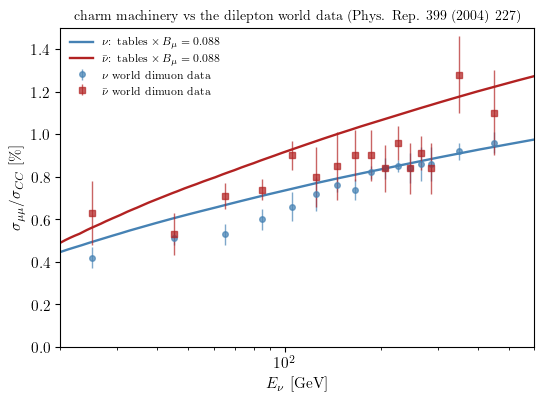

In [7]:
# world-average dimuon rates (percent of CC), review Tables 8 and 9
E_nu_d   = np.array([25, 45, 65, 85, 105, 125, 145, 165, 185, 205, 225,
                     245, 265, 285, 350, 450])
r_nu_d   = np.array([0.42, 0.51, 0.53, 0.60, 0.66, 0.72, 0.76, 0.74, 0.82,
                     0.84, 0.85, 0.84, 0.86, 0.86, 0.92, 0.96])
e_nu_d   = np.array([0.05, 0.03, 0.05, 0.05, 0.07, 0.08, 0.03, 0.05, 0.03,
                     0.05, 0.03, 0.07, 0.08, 0.08, 0.04, 0.05])
E_nub_d  = np.array([25, 45, 65, 85, 105, 125, 145, 165, 185, 205, 225,
                     245, 265, 285, 350, 450])
r_nub_d  = np.array([0.63, 0.53, 0.71, 0.74, 0.90, 0.80, 0.85, 0.90, 0.90,
                     0.84, 0.96, 0.84, 0.91, 0.84, 1.28, 1.10])
e_nub_d  = np.array([0.15, 0.10, 0.06, 0.05, 0.07, 0.14, 0.16, 0.12, 0.12,
                     0.11, 0.08, 0.12, 0.08, 0.12, 0.18, 0.20])

B_MU = 0.088    # review Eq. (97): measured effective semi-muonic BR, E>30 GeV
Eg_c = np.geomspace(20, 600, 200)
fig, ax = pt.std_fig(figsize=(6, 4.2))
for lab, c, Ed, rd, ed in [("numu", "steelblue", E_nu_d, r_nu_d, e_nu_d),
                           ("numubar", "firebrick", E_nub_d, r_nub_d, e_nub_d)]:
    pred = (nts.sigma_charm_cc(Eg_c, lab) / xsecs.sigma_CC(Eg_c, lab)
            * B_MU * 100)
    ax.plot(Eg_c, pred, color=c, lw=1.7,
            label=(r"$\nu$" if lab == "numu" else r"$\bar\nu$")
            + r": tables $\times\, B_\mu = 0.088$")
    ax.errorbar(Ed, rd, yerr=ed, fmt="o" if lab == "numu" else "s", ms=4,
                color=c, alpha=0.7, lw=1,
                label=(r"$\nu$" if lab == "numu" else r"$\bar\nu$")
                + " world dimuon data")
ax.set_xscale("log")
ax.set_xlim(20, 600)
ax.set_ylim(0, 1.5)
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$\sigma_{\mu\mu}/\sigma_{CC}$ [\%]")
ax.legend(frameon=False, fontsize=8)
ax.set_title("charm machinery vs the dilepton world data "
             "(Phys. Rep. 399 (2004) 227)", fontsize=10)
fig.savefig("plots/wrongsign_dimuon_validation.pdf", bbox_inches="tight", dpi=300)

print(f"our B_eff = sum f_h BR_h = {nts.wrongsign_br_eff():.4f}")
print("measured  B_mu = 0.088 +- 0.006 (E>30 GeV) | 0.083 +- 0.013 (CHORUS)")
for E0 in (150.0, 250.0, 450.0):
    E_ = np.array([E0])
    print(f"E = {E0:4.0f} GeV: pred nu {float(nts.sigma_charm_cc(E_, 'numu')/xsecs.sigma_CC(E_, 'numu'))*B_MU*100:.2f}% "
          f"| nubar {float(nts.sigma_charm_cc(E_, 'numubar')/xsecs.sigma_CC(E_, 'numubar'))*B_MU*100:.2f}%")

## 6. Baseline dependence (with and without beam dynamics)

Wrong-sign CC events per year vs the detector distance $D$ (both detectors
moved symmetrically; rock from the end of the straight to $D - 10$ m). The
collinear sources (IMD, $e\mu$ tridents) integrate the full growing rock
column, so they fall more slowly than the flux; the soft, mrad-scale charm
component tracks the flux. Solid: beam dynamics on; thin dashed: off (ideal
orbit, no divergence/momentum spread) -- as for the $\nu_\tau$ sources, the
$\sim$0.6 mrad IP divergence is what makes the rates fall at large $D$.

In [8]:
D_scan = np.geomspace(1e5, 50e5, 9)
Dkm = D_scan / 1e5

def cc_of(flux_binned, flavor):
    return float(np.sum(flux_binned * xsecs.sigma_CC(Enu_c, flavor)
                        * det.cc_correction(Enu_c, flavor) * col_det))

# (primary, face sign, wrong-sign flavor, beam tag)
WS_CHANNELS = [("nue", +1, "numu", "p"), ("numubar", +1, "nuebar", "p"),
               ("nuebar", -1, "numubar", "m"), ("numu", -1, "nue", "m")]

# The benchmark aperture grows with D (R = 2.5 sigma_spot, sigma_spot ~ D), so
# "the detector at D" is a detector rebuilt at each D. Mixing that with a fixed
# acceptance radius makes the scan artificially flat -- see the note in
# notebook 2. Here the FIXED 5 km build (R = 1.28 m) is carried to each D and
# used for both the flux and the wrong-sign angular acceptance.
R_FIXED = det.radius

def ws_scan(sims_d, rng0=60, R_of=lambda D: R_FIXED):
    out = {k: [] for k in ("charm_p", "charm_m", "imd_m", "tri_p", "tri_m")}
    for D in D_scan:
        tots = {k: 0.0 for k in out}
        for prim, sg, wsfl, side in WS_CHANNELS:
            R = R_of(D)
            E_, w_, *_ = det.face_rays(sims_d[prim], sign=sg,
                                       exposure=injections_per_year,
                                       dist=D, r_sel=R)
            Ec_, W_ = dt.bin_flux(E_, w_)
            f_ch = nts.wrongsign_flux_charm_mc(
                Ec_, W_, prim, rock, Lss_half, D - GAP, D, R, Enu_edges,
                n_mc=250_000, rng=rng0)
            tots[f"charm_{side}"] += cc_of(f_ch, wsfl)
            f_tr = nts.wrongsign_flux_trident_mc(
                Ec_, W_, prim, rock, Lss_half, D - GAP, D, R, Enu_edges,
                n_mc=150_000, rng=rng0 + 1)
            tots[f"tri_{side}"] += cc_of(f_tr, wsfl)
            if side == "m":
                f_imd = nts.wrongsign_flux_imd_mc(
                    Ec_, W_, prim, rock, Lss_half, D - GAP, D, R,
                    Enu_edges, n_mc=200_000, rng=rng0 + 2)
                tots["imd_m"] += cc_of(f_imd, wsfl)
        for k in out:
            out[k].append(tots[k])
        print(f"D = {D/1e5:5.1f} km: "
              + " | ".join(f"{k} {tots[k]:.3f}" for k in out))
    return {k: np.array(v) for k, v in out.items()}

print("beam dynamics ON:")
scan_on = ws_scan(sims)
print("\nbeam dynamics OFF:")
_, sims_nb, _ = mint.examples.both_beams(beam_dynamics=False)
scan_off = ws_scan(sims_nb, rng0=70)

beam dynamics ON:


D =   1.0 km: charm_p 0.628 | charm_m 0.732 | imd_m 1.199 | tri_p 0.028 | tri_m 0.036


D =   1.6 km: charm_p 0.676 | charm_m 0.791 | imd_m 1.975 | tri_p 0.036 | tri_m 0.046


D =   2.7 km: charm_p 0.673 | charm_m 0.789 | imd_m 2.895 | tri_p 0.041 | tri_m 0.053


D =   4.3 km: charm_p 0.604 | charm_m 0.700 | imd_m 3.495 | tri_p 0.040 | tri_m 0.052


...

D =   7.1 km: charm_p 0.827 | charm_m 0.981 | imd_m 6.010 | tri_p 0.061 | tri_m 0.079


D =  11.5 km: charm_p 0.841 | charm_m 1.004 | imd_m 6.809 | tri_p 0.065 | tri_m 0.085


D =  18.8 km: charm_p 0.872 | charm_m 1.025 | imd_m 7.306 | tri_p 0.068 | tri_m 0.088


D =  30.7 km: charm_p 0.886 | charm_m 1.042 | imd_m 7.611 | tri_p 0.069 | tri_m 0.091


D =  50.0 km: charm_p 0.865 | charm_m 0.998 | imd_m 7.472 | tri_p 0.068 | tri_m 0.089


charm_m : on peaks at 1.6 km (0.79/yr); off at 50 km: 1.00/yr
charm_p : on peaks at 1.6 km (0.68/yr); off at 50 km: 0.87/yr
imd_m   : on peaks at 4.3 km (3.49/yr); off at 50 km: 7.47/yr
tri_m   : on peaks at 2.7 km (0.05/yr); off at 50 km: 0.09/yr
tri_p   : on peaks at 2.7 km (0.04/yr); off at 50 km: 0.07/yr


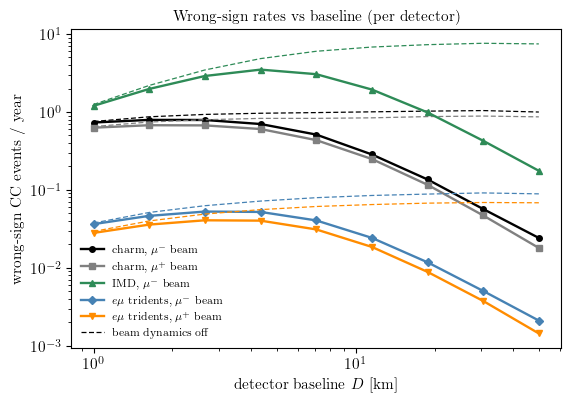

In [9]:
fig, ax = pt.std_fig(figsize=(6.2, 4.2))
STYLES = [
    ("charm_m", "black", "o", r"charm, $\mu^-$ beam"),
    ("charm_p", "gray", "s", r"charm, $\mu^+$ beam"),
    ("imd_m", "seagreen", "^", r"IMD, $\mu^-$ beam"),
    ("tri_m", "steelblue", "D", r"$e\mu$ tridents, $\mu^-$ beam"),
    ("tri_p", "darkorange", "v", r"$e\mu$ tridents, $\mu^+$ beam"),
]
for key, c, mk, lab in STYLES:
    ax.plot(Dkm, scan_on[key], "-", marker=mk, color=c, lw=1.7, ms=4,
            label=lab)
    ax.plot(Dkm, scan_off[key], color=c, lw=0.9, ls=(0, (4, 2)))
ax.plot([], [], color="k", lw=0.9, ls=(0, (4, 2)), label="beam dynamics off")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"detector baseline $D$ [km]")
ax.set_ylabel(r"wrong-sign CC events / year")
ax.set_title(r"Wrong-sign rates vs baseline (per detector)", fontsize=11)
ax.legend(frameon=False, fontsize=8)
fig.savefig("plots/wrongsign_baseline_scan.pdf", bbox_inches="tight", dpi=300)

for key, _, _, lab in STYLES:
    i_on = int(np.argmax(scan_on[key]))
    print(f"{key:8s}: on peaks at {Dkm[i_on]:.1f} km ({scan_on[key][i_on]:.2f}/yr); "
          f"off at 50 km: {scan_off[key][-1]:.2f}/yr")

## 7. Notes

- The **IMD prompt $\bar\nu_\mu$** dominates the wrong-sign muon-flavor
  contamination in the $\mu^-$ beam at high energy: it is collinear (whole
  rock column) and hard ($u^2$ spectrum from the annihilation V--A weight),
  exactly where a wrong-sign muon would fake new physics. The $\mu^+$ beam
  has **no IMD channels** (lepton number with only $e^-$ targets), so its
  contamination is charm-only and much softer.
- The charm component uses the same production machinery as the $\nu_\tau$
  chains (one shared `_charm_quark` sampler), with the 3-body constant-$f_+$
  semileptonic decay; $D\to K^*\ell\nu$ (treated here as $K\ell\nu$)
  slightly hardens the true neutrino spectrum, and $\Lambda_c$/NC-charm/
  leptonic modes are neglected (few-% level of an already small flux).
- The **$e\mu$ tridents** take over the wrong-sign flux at the highest
  energies: the prompt neutrino carries $\sim$half the beam energy and is
  collinear, while the charm component is soft. Their cross sections
  ($4$--$6\times10^{-39}$ cm$^2$/nucleus at 1 TeV on rock) are 2--5$\times$
  the $\ell\tau$ ones of notebook 2 (no $\tau$-mass suppression).
- Primary spectra are histogrammed from the **raw** MC flux; re-histogramming
  the binned `bin_flux` grid onto different edges aliases into a castle-wall
  pattern (the binned form is only a quadrature/sampling input).
- **Associated $c\bar{c}$ production** is a further neglected wrong-sign
  source (De Lellis et al., Phys. Rep. 399 (2004) 227): the CC mode
  ($3.9\times10^{-4}$/CC, CHORUS) contributes at the $\sim$1% level of the
  rates computed here; the gluon-driven NC mode ($6.5\times10^{-3}$/NC at
  154 GeV and growing with energy) is an $\mathcal{O}(5-10\%)$ systematic
  at TeV energies. Diffractive $D_s$ adds $\sim$2–5% to the DIS charm yield.
- Oscillations over 5 km are negligible at these energies; the contamination
  quoted here is purely from rock regeneration.
- Neglected wrong-sign sources: $D_s\to\tau\nu_\tau$ with
  $\tau\to\mu\nu_\mu\bar\nu_\tau$ (an additional $\sim$1% of the charm
  wrong-sign rate), and muon decay in flight (suppressed by
  range$/\gamma c\tau \sim 10^{-5}$).